# 04 — Topic Analysis & Interpretation

Understand topic keywords, dominant topics, document mixtures, and unseen-document inference.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from gensim.corpora import Dictionary
from gensim.models import LdaModel

df=pd.read_pickle("../data/ag_news_preprocessed.pkl")
dictionary=Dictionary.load("../models/news_dictionary.gensim")
lda_model=LdaModel.load("../models/lda_model.gensim")
corpus=[dictionary.doc2bow(tokens) for tokens in df["tokens"]]

In [2]:
for topic_id in range(lda_model.num_topics):
    terms=lda_model.show_topic(topic_id,topn=12)
    print(f"\nTopic {topic_id+1}: "+", ".join(w for w,_ in terms))


Topic 1: said, united, president, court, yesterday, says, former, chief, states, bush, washington, european

Topic 2: reuters, oil, percent, said, prices, china, new, york, year, sales, thursday, friday

Topic 3: said, iraq, minister, reuters, killed, people, leader, prime, police, two, palestinian, iraqi

Topic 4: game, first, season, night, team, last, coach, win, world, points, second, victory

Topic 5: new, years, next, one, may, year, first, two, now, time, mobile, today

Topic 6: company, inc, new, microsoft, corp, million, software, said, search, internet, announced, business


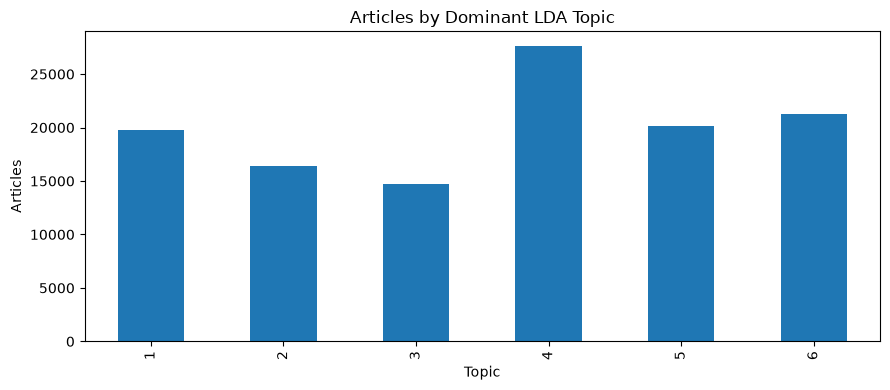

In [3]:
dominant=[]
for bow in corpus:
    dist=lda_model.get_document_topics(bow,minimum_probability=0)
    dominant.append(max(dist,key=lambda x:x[1])[0]+1)
df["dominant_topic"]=dominant
plt.figure(figsize=(9,4)); df["dominant_topic"].value_counts().sort_index().plot(kind="bar")
plt.title("Articles by Dominant LDA Topic"); plt.xlabel("Topic"); plt.ylabel("Articles"); plt.tight_layout(); plt.show()

In [4]:
for i in range(5):
    dist=sorted(lda_model.get_document_topics(corpus[i],minimum_probability=0),key=lambda x:x[1],reverse=True)
    print("\nARTICLE:",df.iloc[i]["text"][:250],"...")
    print("TOPICS:",[(t+1,round(p,3)) for t,p in dist[:3]])


ARTICLE: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again. ...
TOPICS: [(2, np.float32(0.425)), (4, np.float32(0.214)), (1, np.float32(0.14))]

ARTICLE: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another par ...
TOPICS: [(2, np.float32(0.425)), (5, np.float32(0.312)), (6, np.float32(0.104))]

ARTICLE: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums. ...
TOPICS: [(2, np.float32(0.734)), (5, np.float32(0.139)), (1, np.float32(0.043))]

ARTICLE: Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Author

## Unseen article inference

This is the same operation used by the Flask application.

In [5]:
stop_words = set("a about above after again against all am an and any are as at be because been before being below between both but by can could did do does doing down during each few for from further had has have having he her here hers herself him himself his how i if in into is it its itself just me more most my myself no nor not of off on once only or other our ours ourselves out over own same she should so some such than that the their theirs them themselves then there these they this those through to too under until up very was we were what when where which while who whom why will with would you your yours yourself yourselves".split())

def clean_text(text):
    import re, string
    text=text.lower(); text=re.sub(r"http\S+|www\S+"," ",text)
    text=text.translate(str.maketrans("","",string.punctuation))
    return [t for t in re.findall(r"[a-z]{3,}",text) if t not in stop_words]

sample_article="Technology companies are investing heavily in artificial intelligence, new data centers and faster computer chips as demand for AI services grows."
bow=dictionary.doc2bow(clean_text(sample_article))
dist=sorted(lda_model.get_document_topics(bow,minimum_probability=0),key=lambda x:x[1],reverse=True)
for topic_id,probability in dist[:5]:
    print(f"Topic {topic_id+1}: {probability:.2%}")

Topic 6: 31.91%
Topic 5: 23.40%
Topic 2: 22.60%
Topic 1: 14.92%
Topic 4: 4.42%


## Interview takeaway

LDA does not automatically assign human names such as Technology or Sports. Those names are analyst interpretations based on topic words and representative documents.